# Part B: DQN for Pendulum Control

This notebook builds a baseline Deep Q-Network and tests how well it balances Pendulum-v0 under four gravity settings: default, free-fall, anti-gravity, and supergravity.


### 1.1 Pendulum Control as a Reinforcement-Learning Problem

The pendulum task asks an agent to pick a torque at every timestep so the pendulum swings up and stays balanced near the top. Each torque choice changes the pendulum's angle and speed, which then affects what torque makes sense on the next step, so the decision made now shapes the situation the agent faces later. That's what makes this a sequential decision problem rather than a one-off prediction, and why reinforcement learning is the right framework: the agent has to weigh the immediate cost of a torque against how it plays out several steps ahead, not just react to the current frame.


### 1.2 From Q-Learning to Deep Q-Networks

Q-learning keeps a table of values, one entry per state-action pair, describing how good it is to take a given action from a given state. Pendulum's state is continuous, an angle and an angular velocity that can take any real value, so there's no way to build a finite table for it; there are infinitely many states. A Deep Q-Network replaces the table with a neural network that takes a state as input and outputs a value for every available action. The network is trained toward the same target that Q-learning uses, so the underlying objective doesn't change, only how the values are stored and updated.


### 1.3 DQN in Continuous-Control Environments

DQN's output layer produces one value per action, so it can only choose from a fixed menu of actions. Pendulum's torque, on the other hand, is a continuous quantity: any value between -2 and 2. To make DQN usable here, the torque range is cut into a small set of fixed choices (Section 4), and DQN picks the best one of those on every step. This is an approximation: the agent can never apply a torque that falls between two of its allowed values, so its control is coarser than a method built for continuous actions. That coarseness is something the results below need to account for.


## 2. Imports and Setup

This section imports the libraries used throughout the notebook, checks that Gym 0.17.3 is available, and fixes the random seed, plotting style, and compute device so the rest of the notebook runs consistently.


In [71]:
# Import the fixed Gym/PyTorch stack and record the runtime for reproducibility.
from __future__ import annotations

import copy
import json
import math
import os
import platform
import random
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Callable

import gym
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

import matplotlib.animation as animation
from IPython.display import Image, display

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Locate the project root by structure so this notebook runs from any working directory.
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "notebooks").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise RuntimeError(
        "Could not locate the project root: expected a parent folder containing notebooks/ and results/."
    )

PROJECT_ROOT = find_project_root(Path.cwd())

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "part_b"          # PyTorch .pt checkpoints, beside the notebooks
RESULTS_DIR = PROJECT_ROOT / "results" / "part_b"             # experiment result JSON
MODEL_CHECKPOINT_DIR = PROJECT_ROOT / "model_checkpoints"     # .h5 deliverable weights, shared project-wide
ROLLOUT_DIR = PROJECT_ROOT / "img" / "rollouts" / "baseline"    # rendered greedy-episode GIFs
CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints" / "rl_baseline"     # local run cache only (gitignored, safe to delete)

for directory in (NOTEBOOK_DIR, RESULTS_DIR, MODEL_CHECKPOINT_DIR, ROLLOUT_DIR, CHECKPOINT_ROOT):
    directory.mkdir(parents=True, exist_ok=True)


plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "default": "#2563eb",
    "free_fall": "#16a34a",
    "anti_gravity": "#9333ea",
    "supergravity": "#dc2626",
}

## 3. Environment Preview and Problem Formulation

Before any agent code is written, this section looks at the Pendulum environment itself: what the agent observes, what it can control, how its actions are scored, and how the task is framed as a decision-making problem.


### 3.1 Create and Render Pendulum-v0

We create the default Pendulum environment, reset it to a starting state, and render a single frame to confirm the environment works and to get a visual sense of what "balanced" looks like: the pendulum standing upright.


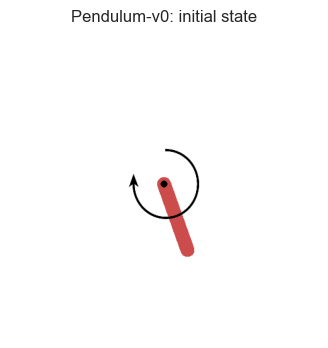

Initial observation: [-0.94223519 -0.33495202  0.93078187]


In [72]:
# Define every gravity condition required by the brief in one shared mapping.
GRAVITY_CONFIGS = {
    "default": 10.0,
    "free_fall": 0.0,
    "anti_gravity": -10.0,
    "supergravity": 15.0,
}

# Seed Python, NumPy, PyTorch, and Gym before each independent run.
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def make_env(gravity_name: str = "default", seed: int = 0):
    if gravity_name not in GRAVITY_CONFIGS:
        raise KeyError(f"Unknown gravity configuration: {gravity_name}")
    kwargs = {} if gravity_name == "default" else {"g": GRAVITY_CONFIGS[gravity_name]}
    env = gym.make("Pendulum-v0", **kwargs)
    env.seed(seed)
    env.action_space.seed(seed)
    return env

seed_everything(0)
preview_env = make_env("default", seed=0)
preview_observation = preview_env.reset()

# Rendering is a visual sanity check only, so headless sessions may skip it safely.
try:
    preview_frame = preview_env.render(mode="rgb_array")
    plt.figure(figsize=(4, 4))
    plt.imshow(preview_frame)
    plt.axis("off")
    plt.title("Pendulum-v0: initial state")
    plt.show()
except Exception as exc:
    print(f"Rendering unavailable in this session: {exc}")
finally:
    preview_env.close()

print("Initial observation:", preview_observation)

### 3.2 Observation Space

The observation the agent receives on every step has three numbers: cos(theta), sin(theta), and the angular velocity. Using cos and sin of the angle rather than the raw angle avoids a wrap-around problem: an angle of 359 degrees and 1 degree are almost the same physical position, but as raw numbers they'd look far apart, which would confuse a neural network. The angular velocity is included separately because two states can have the same angle but be moving in opposite directions, and the agent needs to tell those apart to choose the right torque.


In [73]:
inspection_env = make_env("default", seed=1)

print("Observation space:", inspection_env.observation_space)
print("Lower bounds:", inspection_env.observation_space.low)
print("Upper bounds:", inspection_env.observation_space.high)

# cos(theta) and sin(theta) are already bounded; only scale angular velocity to [-1, 1].
def normalize_state(state: np.ndarray) -> np.ndarray:
    normalized = np.asarray(state, dtype=np.float32).copy()
    normalized[2] /= 8.0
    return normalized

sample_state = inspection_env.reset()
print("Raw state:", sample_state)
print("Normalized state:", normalize_state(sample_state))
inspection_env.close()

Observation space: Box(-8.0, 8.0, (3,), float32)
Lower bounds: [-1. -1. -8.]
Upper bounds: [1. 1. 8.]
Raw state: [-0.35283079  0.93568715  0.02900014]
Normalized state: [-0.3528308   0.9356871   0.00362502]


### 3.3 Continuous Action Space

Pendulum-v0's native action is a single real-valued torque, bounded between -2 and 2. This is incompatible with a standard DQN output layer, which produces one Q-value per discrete action rather than a continuous value: DQN has no way to output "apply 1.37 units of torque" directly. That mismatch is why the action space needs to be discretized before DQN can be applied, which is handled in Section 4.


In [74]:
inspection_env = make_env("default", seed=2)
print("Native action space:", inspection_env.action_space)
print("Minimum torque:", float(inspection_env.action_space.low[0]))
print("Maximum torque:", float(inspection_env.action_space.high[0]))
inspection_env.close()

Native action space: Box(-2.0, 2.0, (1,), float32)
Minimum torque: -2.0
Maximum torque: 2.0


### 3.4 Reward Function

Gym's Pendulum reward penalizes three things at once: how far the angle is from upright, how fast the pendulum is spinning, and how much torque was applied. All three terms are squared and subtracted, so the reward is always zero or negative, and a return closer to zero means better control. The small penalty on torque discourages the agent from spamming maximum torque and rewards it for finding a solution that's also efficient, not just accurate.


In [75]:
def angle_normalize(angle: float) -> float:
    return ((angle + np.pi) % (2 * np.pi)) - np.pi

# Reproduce Gym's reward equation to confirm the notebook interprets return correctly.
def expected_reward(theta: float, angular_velocity: float, torque: float) -> float:
    cost = angle_normalize(theta) ** 2 + 0.1 * angular_velocity ** 2 + 0.001 * torque ** 2
    return -float(cost)

reward_env = make_env("default", seed=3)
reward_env.reset()
theta, angular_velocity = reward_env.unwrapped.state.copy()
test_torque = np.array([1.0], dtype=np.float32)
_, observed_reward, _, _ = reward_env.step(test_torque)
calculated_reward = expected_reward(theta, angular_velocity, float(test_torque[0]))
reward_env.close()

print(f"Observed reward:   {observed_reward:.8f}")
print(f"Calculated reward: {calculated_reward:.8f}")
assert np.isclose(observed_reward, calculated_reward), "Reward calculation does not match the environment."

Observed reward:   -2.07997375
Calculated reward: -2.07997375


### 3.5 Required Gravity Configurations

We test the agent under four gravity values: the environment's own default, free-fall (g = 0), anti-gravity (g = -10), and supergravity (g = 15). We create one environment per setting and check that Gym actually applied the intended gravity value, so later results can be trusted to reflect the condition they claim to be testing.


In [76]:
# Instantiate each environment and verify that Gym received the intended gravity value.
gravity_rows = []
for gravity_name, expected_g in GRAVITY_CONFIGS.items():
    env = make_env(gravity_name, seed=4)
    actual_g = float(env.unwrapped.g)
    gravity_rows.append({"configuration": gravity_name, "g": actual_g})
    assert np.isclose(actual_g, expected_g)
    env.close()

gravity_table = pd.DataFrame(gravity_rows)
gravity_table

,configuration,g
0,default,10.0
1,free_fall,0.0
2,anti_gravity,-10.0
3,supergravity,15.0


### 3.6 Markov Decision Process Formulation

Writing the task as a Markov Decision Process makes explicit what the agent is actually solving. The state is the three-value observation from Section 3.2, the action is one of the five torque bins from Section 4, the transition is Pendulum's own physics simulation (unknown to the agent, and different under each gravity setting), and the reward is the cost function from Section 3.4. A discount factor and a fixed 200-step horizon complete the formulation, both used later when computing Bellman targets during training.


In [77]:
mdp_summary = pd.DataFrame(
    {
        "Component": ["State S", "Action A", "Transition P", "Reward R", "Discount", "Horizon"],
        "Definition": [
            "[cos(theta), sin(theta), angular velocity]",
            "Five torque bins spanning [-2, 2]",
            "Unknown Pendulum-v0 dynamics under each gravity",
            "-(angle_error^2 + 0.1*velocity^2 + 0.001*torque^2)",
            "gamma = 0.99",
            "200 environment steps",
        ],
    }
)
mdp_summary

,Component,Definition
0,State S,"[cos(theta), sin(theta), angular velocity]"
1,Action A,"Five torque bins spanning [-2, 2]"
2,Transition P,Unknown Pendulum-v0 dynamics under each gravity
3,Reward R,-(angle_error^2 + 0.1*velocity^2 + 0.001*torqu...
4,Discount,gamma = 0.99
5,Horizon,200 environment steps


### 3.7 Episode Horizon and Time-Limit Truncation

Pendulum has no natural terminal state: the pendulum never "dies," it just keeps swinging. Every episode instead ends because Gym enforces a fixed 200-step limit. This distinction matters for training. If the 200-step cutoff is treated as a true terminal state, the agent is taught that good states suddenly have zero future value at step 200, which isn't true and would bias the value estimates. We confirm this by stepping the environment for exactly 200 steps and checking that Gym reports the episode ending through its time-limit flag rather than a physical failure.


In [78]:
truncation_env = make_env("default", seed=5)
truncation_env.reset()
last_done, last_info = False, {}

# Pendulum-v0 ends through the 200-step TimeLimit, not a physical terminal state.
for step_index in range(200):
    _, _, last_done, last_info = truncation_env.step(np.array([0.0], dtype=np.float32))

truncation_env.close()
print("Done after 200 steps:", last_done)
print("Info:", last_info)
print("Time-limit truncation:", bool(last_info.get("TimeLimit.truncated", False)))
assert last_done and last_info.get("TimeLimit.truncated", False)

Done after 200 steps: True
Info: {'TimeLimit.truncated': True}
Time-limit truncation: True


### 3.8 Non-Learning Reference Policies

A DQN return on its own doesn't say much: is -200 good or bad without something to compare it to? We evaluate two simple non-learning policies, choosing a random torque bin and always applying zero torque. Their returns give an honest floor: any trained agent that doesn't clearly beat both of these hasn't actually learned anything useful, no matter how the training curve looks.


In [79]:
# Evaluate simple non-learning policies to give DQN returns a meaningful reference point.
def run_reference_policy(
    gravity_name: str,
    policy: Callable[[np.random.Generator], int],
    episode_seeds: list[int],
) -> list[float]:
    returns = []
    for episode_seed in episode_seeds:
        env = make_env(gravity_name, episode_seed)
        state = env.reset()
        rng = np.random.default_rng(episode_seed)
        episode_return = 0.0

        for _ in range(200):
            action_index = policy(rng)
            action = action_index_to_env(action_index)
            state, reward, done, _ = env.step(action)
            episode_return += reward
            if done:
                break

        returns.append(float(episode_return))
        env.close()
    return returns

## 4. Action-Space Discretization

This section converts Pendulum's continuous torque range into a small, fixed set of actions that a standard DQN can choose between.


### 4.1 Why DQN Requires Discrete Actions

A DQN predicts one Q-value per available action and then selects whichever action has the highest predicted value. That only works when the number of actions is fixed and small, since the network's output layer has to have exactly that many units. A continuous action space has infinitely many possible values, so there's no way to give DQN one output per action without first reducing the action space to a finite list.


### 4.2 Uniform Torque Bins

We split the torque range into five evenly spaced values across [-2, 2]: -2, -1, 0, 1, and 2. Five bins is enough to include full torque in both directions, zero torque for coasting, and two intermediate values, while keeping the action space small enough for exploration to work in a reasonable number of episodes. The bins are symmetric around zero because the pendulum can fall to either side and there's no reason to bias the action set toward one direction.


,action_index,torque,interpretation
0,0,-2.0,maximum left
1,1,-1.0,moderate left
2,2,0.0,no torque
3,3,1.0,moderate right
4,4,2.0,maximum right


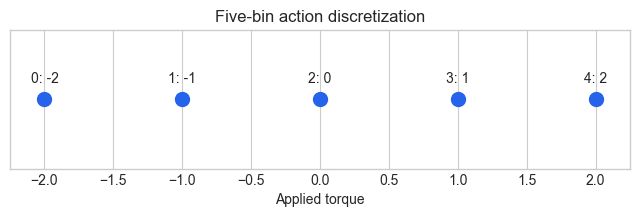

In [80]:
# Convert the continuous torque range into five symmetric, uniformly spaced DQN actions.
ACTION_BINS = np.linspace(-2.0, 2.0, num=5, dtype=np.float32)

assert len(ACTION_BINS) == 5
assert np.isclose(ACTION_BINS[0], -2.0)
assert np.isclose(ACTION_BINS[-1], 2.0)
assert np.any(np.isclose(ACTION_BINS, 0.0))
assert np.allclose(ACTION_BINS, -ACTION_BINS[::-1])

action_table = pd.DataFrame(
    {
        "action_index": np.arange(len(ACTION_BINS)),
        "torque": ACTION_BINS,
        "interpretation": [
            "maximum left",
            "moderate left",
            "no torque",
            "moderate right",
            "maximum right",
        ],
    }
)
display(action_table)

fig, ax = plt.subplots(figsize=(8, 1.8))
ax.scatter(ACTION_BINS, np.zeros_like(ACTION_BINS), s=100, color="#2563eb")
for index, torque in enumerate(ACTION_BINS):
    ax.annotate(f"{index}: {torque:g}", (torque, 0), xytext=(0, 12), textcoords="offset points", ha="center")
ax.set_xlim(-2.25, 2.25)
ax.set_yticks([])
ax.set_xlabel("Applied torque")
ax.set_title("Five-bin action discretization")
plt.show()

### 4.3 Mapping DQN Outputs to Environment Actions

DQN outputs an index (0 to 4) identifying which of the five bins it picked. Gym expects an action formatted as a one-element array holding the actual torque value. We convert between the two, turning an index like 3 into the array [1.0], so the agent's decision can actually be sent to the environment.


In [81]:
# Map a discrete Q-network output index back to Gym's one-value continuous action array.
def action_index_to_env(action_index: int) -> np.ndarray:
    if not 0 <= int(action_index) < len(ACTION_BINS):
        raise IndexError(f"Action index {action_index} is outside [0, {len(ACTION_BINS) - 1}].")
    return np.array([ACTION_BINS[int(action_index)]], dtype=np.float32)

for action_index, expected_torque in enumerate(ACTION_BINS):
    mapped_action = action_index_to_env(action_index)
    assert mapped_action.shape == (1,)
    assert mapped_action.dtype == np.float32
    assert np.isclose(mapped_action[0], expected_torque)

# Use fixed episode seeds so random, zero-torque, and learned policies face comparable starts.
REFERENCE_SEEDS = list(range(3001, 3101))
if os.getenv("RL_RUN_PROFILE", "full").lower() == "smoke":
    REFERENCE_SEEDS = REFERENCE_SEEDS[:2]

reference_results = {}
for gravity_name in GRAVITY_CONFIGS:
    reference_results[gravity_name] = {
        "random": run_reference_policy(
            gravity_name,
            policy=lambda rng: int(rng.integers(len(ACTION_BINS))),
            episode_seeds=REFERENCE_SEEDS,
        ),
        "zero_torque": run_reference_policy(
            gravity_name,
            policy=lambda rng: 2,
            episode_seeds=REFERENCE_SEEDS,
        ),
    }

reference_summary = pd.DataFrame(
    [
        {
            "gravity": gravity_name,
            "policy": policy_name,
            "mean_return": np.mean(returns),
            "std_return": np.std(returns, ddof=1) if len(returns) > 1 else 0.0,
        }
        for gravity_name, policy_results in reference_results.items()
        for policy_name, returns in policy_results.items()
    ]
)
reference_summary

,gravity,policy,mean_return,std_return
0,default,random,-1192.495835,257.894997
1,default,zero_torque,-1209.557797,362.590205
2,free_fall,random,-751.517710,217.921472
3,free_fall,zero_torque,-628.898820,321.814881
4,anti_gravity,random,-656.040290,466.124120
5,anti_gravity,zero_torque,-586.849914,479.907757
6,supergravity,random,-1398.271864,157.778011
7,supergravity,zero_torque,-1411.380513,198.460112


### 4.4 Discretization Trade-off and Limitation

Fewer bins make exploration easier, since there are fewer options to try and less time needed to sample all of them, but they also limit how precisely the agent can control torque; it can never apply, say, 0.5 units if that's not one of its five choices. More bins would allow finer control but slow down exploration and training, since the agent has more options to evaluate before it can tell which ones are good. Five bins is a starting point for the baseline; whether a different number of bins improves performance is a natural question for the follow-up experiments.


## 5. DQN Approach and Architecture

This section works through the parts that make up a vanilla DQN agent and how they fit together for this discretized pendulum task.


### 5.1 Why DQN Is Suitable

With the state already a fixed set of continuous numbers (Section 3.2) and the action space reduced to five discrete choices (Section 4), the task now matches exactly what DQN expects: continuous input, discrete output. DQN also gives a clear baseline against which later improvements, double DQN, dueling networks, and so on, can be measured.

The limitation is built into that same setup: DQN can only ever choose one of the five torque bins from Section 4, so its control gets coarser exactly when the pendulum needs finer torque adjustments. That's the failure mode Sections 9 and 10 come back to under the harder gravity settings.


### 5.2 Q-Learning Objective

The network learns to predict Q(s, a): the expected total future reward from taking action a in state s and then acting well afterward. Training pushes the network's prediction toward a target built from the Bellman equation, the reward just received plus the discounted value of the best action in the next state. The gap between the current prediction and this target is the temporal-difference error, and the network is updated to shrink that gap. Since the reward and the next state come from actually interacting with the environment, this target improves as the agent gathers more experience.


### 5.3 Experience Replay

Instead of learning only from the transition that just happened, the agent stores every transition it experiences in a replay buffer and learns from randomly sampled batches of past transitions. Consecutive steps in an episode are highly correlated (the pendulum's state barely changes from one timestep to the next), and training directly on that correlated stream tends to make the network overfit to whatever situation it's currently in. Sampling randomly from a buffer of past experience breaks that correlation and also lets each transition be reused for multiple updates instead of being seen once and discarded.


### 5.4 Target Network

The Bellman target in Section 5.2 depends on the network's own prediction of the next state's value. If the same network that's being updated is also used to compute its own target, the target shifts every time the network is updated, which can make training oscillate or diverge. A target network is a separate copy of the Q-network whose weights are frozen and only copied over from the online network at fixed intervals. Computing targets from this slower-moving copy keeps the learning signal stable enough for training to converge.


### 5.5 Epsilon-Greedy Exploration

The agent explores by choosing a random action with probability epsilon, and otherwise picks whatever action the network currently rates highest. Epsilon starts near 1 so training begins by trying actions broadly rather than committing early to whatever the untrained network happens to prefer, and decays toward a small value as training progresses so the agent increasingly exploits what it has learned. Without this decay, the agent would either never stop acting randomly or would lock onto an early, possibly bad, policy before it's had a chance to explore alternatives.


### 5.6 Neural-Network Architecture

The network is a small fully connected model. The three-value state goes in, passes through two hidden layers of 128 units each with ReLU activations, and comes out as five linear Q-values, one per torque bin. This size is intentionally modest: the state space here is only three numbers, so a much larger network would mostly add training instability without giving the model more useful capacity.


In [82]:
architecture_table = pd.DataFrame(
    [
        {"layer": "Input", "units": 3, "activation": "None"},
        {"layer": "Hidden 1", "units": 128, "activation": "ReLU"},
        {"layer": "Hidden 2", "units": 128, "activation": "ReLU"},
        {"layer": "Output", "units": len(ACTION_BINS), "activation": "Linear Q-values"},
    ]
)
architecture_table

,layer,units,activation
0,Input,3,None
1,Hidden 1,128,ReLU
2,Hidden 2,128,ReLU
3,Output,5,Linear Q-values


### 5.7 Baseline Hyperparameters and Selection Source

We list every fixed hyperparameter for the baseline, together with where each value came from: established DQN literature, the CartPole lab, or a preliminary choice made before any tuning was done. None of these values have been tuned against the results in this notebook; they represent a reasonable starting configuration, and any systematic tuning of them is left to the improvement notebook so this baseline stays a genuine first attempt rather than a result that's already been optimized.


In [83]:
# Store all baseline choices in one immutable configuration for repeatable checkpoints.
@dataclass(frozen=True)
class DQNConfig:
    state_dim: int = 3
    action_dim: int = 5
    hidden_dims: tuple[int, int] = (128, 128)
    learning_rate: float = 1e-3
    gamma: float = 0.99
    batch_size: int = 64
    replay_capacity: int = 100_000
    replay_warmup: int = 2_000
    train_frequency: int = 4
    target_update_frequency: int = 1_000
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_steps: int = 60_000
    gradient_clip_norm: float = 10.0
    episodes: int = 600
    max_steps: int = 200
    evaluation_frequency: int = 25
    upright_angle_degrees: float = 12.0
    upright_velocity: float = 1.0

CONFIG = DQNConfig()
TRAIN_SEEDS = [11, 22, 33, 44, 55]
DEVELOPMENT_EVAL_SEEDS = list(range(1001, 1011))
FINAL_EVAL_SEEDS = list(range(2001, 2011))

# The smoke profile exercises the full pipeline quickly without changing the reported setup.
RUN_PROFILE = os.getenv("RL_RUN_PROFILE", "full").lower()
if RUN_PROFILE not in {"full", "smoke"}:
    raise ValueError("RL_RUN_PROFILE must be either 'full' or 'smoke'.")

if RUN_PROFILE == "smoke":
    ACTIVE_CONFIG = replace(
        CONFIG,
        episodes=2,
        max_steps=30,
        batch_size=8,
        replay_capacity=256,
        replay_warmup=8,
        train_frequency=1,
        target_update_frequency=10,
        epsilon_decay_steps=30,
        evaluation_frequency=1,
    )
    ACTIVE_TRAIN_SEEDS = TRAIN_SEEDS[:1]
    ACTIVE_DEVELOPMENT_SEEDS = DEVELOPMENT_EVAL_SEEDS[:2]
    ACTIVE_FINAL_SEEDS = FINAL_EVAL_SEEDS[:2]
else:
    ACTIVE_CONFIG = CONFIG
    ACTIVE_TRAIN_SEEDS = TRAIN_SEEDS
    ACTIVE_DEVELOPMENT_SEEDS = DEVELOPMENT_EVAL_SEEDS
    ACTIVE_FINAL_SEEDS = FINAL_EVAL_SEEDS

hyperparameter_sources = pd.DataFrame(
    [
        ("Hidden layers", str(CONFIG.hidden_dims), "Small MLP for the three-value state"),
        ("Learning rate", CONFIG.learning_rate, "Conservative Adam baseline"),
        ("Discount factor", CONFIG.gamma, "Standard long-horizon DQN setting"),
        ("Replay capacity", CONFIG.replay_capacity, "Covers most of one 120k-step run"),
        ("Batch size", CONFIG.batch_size, "Common DQN mini-batch size"),
        ("Warm-up", CONFIG.replay_warmup, "Collect experience before updates"),
        ("Target update", CONFIG.target_update_frequency, "Fixed hard-update schedule"),
        ("Action bins", CONFIG.action_dim, "Uniform five-action literature precedent"),
    ],
    columns=["hyperparameter", "value", "selection rationale"],
)
print("Run profile:", RUN_PROFILE)
hyperparameter_sources

Run profile: full


,hyperparameter,value,selection rationale
0,Hidden layers,"(128, 128)",Small MLP for the three-value state
1,Learning rate,0.001,Conservative Adam baseline
2,Discount factor,0.99,Standard long-horizon DQN setting
3,Replay capacity,100000,Covers most of one 120k-step run
4,Batch size,64,Common DQN mini-batch size
5,Warm-up,2000,Collect experience before updates
6,Target update,1000,Fixed hard-update schedule
7,Action bins,5,Uniform five-action literature precedent


### 5.8 DQN Training Algorithm

Each training step follows the same loop: observe the current state, choose an action with epsilon-greedy selection, apply it and observe the reward and next state, store that transition in the replay buffer, and once enough transitions have been collected, sample a batch and update the online network toward its Bellman targets. The target network is synchronized to the online network every fixed number of steps, and the agent is evaluated periodically so its progress can be tracked and its best checkpoint saved.


## 6. DQN Implementation

This section implements the pieces described above: the replay buffer, the Q-network, the agent that ties them together, and the training and evaluation utilities used in the rest of the notebook.


### 6.1 Replay Buffer

The buffer stores a fixed number of past transitions in preallocated NumPy arrays rather than a Python list, so that storing and sampling stay fast even once it holds tens of thousands of transitions. When it's full, the oldest transition is overwritten first, so it always reflects the agent's most recent experience while dropping older, less relevant data.


In [84]:
# Store transitions in fixed NumPy arrays to avoid Python-object overhead during sampling.
class ReplayBuffer:
    def __init__(self, capacity: int, state_dim: int, seed: int):
        self.capacity = int(capacity)
        self.state_dim = int(state_dim)
        self.rng = np.random.default_rng(seed)
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.terminated = np.zeros(capacity, dtype=np.bool_)
        self.position = 0
        self.size = 0

    def __len__(self) -> int:
        return self.size

    def add(self, state, action, reward, next_state, terminated) -> None:
        index = self.position
        self.states[index] = state
        self.actions[index] = action
        self.rewards[index] = reward
        self.next_states[index] = next_state
        self.terminated[index] = terminated
        # Once full, the circular pointer overwrites the oldest transition.
        self.position = (self.position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int, device: torch.device):
        if batch_size > self.size:
            raise ValueError("Cannot sample more transitions than the buffer contains.")
        indices = self.rng.choice(self.size, size=batch_size, replace=False)
        return (
            torch.as_tensor(self.states[indices], device=device),
            torch.as_tensor(self.actions[indices], device=device),
            torch.as_tensor(self.rewards[indices], device=device),
            torch.as_tensor(self.next_states[indices], device=device),
            torch.as_tensor(self.terminated[indices], device=device),
        )

    def state_dict(self) -> dict:
        return {
            "states": self.states,
            "actions": self.actions,
            "rewards": self.rewards,
            "next_states": self.next_states,
            "terminated": self.terminated,
            "position": self.position,
            "size": self.size,
            "rng_state": self.rng.bit_generator.state,
        }

    def load_state_dict(self, state: dict) -> None:
        for name in ("states", "actions", "rewards", "next_states", "terminated"):
            getattr(self, name)[:] = state[name]
        self.position = int(state["position"])
        self.size = int(state["size"])
        self.rng.bit_generator.state = state["rng_state"]

buffer_test = ReplayBuffer(capacity=4, state_dim=3, seed=0)
for index in range(5):
    state = np.full(3, index, dtype=np.float32)
    buffer_test.add(state, index % 5, float(index), state + 1, False)

assert len(buffer_test) == 4
assert buffer_test.sample(2, DEVICE)[0].shape == (2, 3)

### 6.2 Q-Network

This class implements the architecture from Section 5.6 in PyTorch: two ReLU hidden layers of 128 units feeding a linear output layer with one value per torque bin. Two identical copies of this network are created later, one trained directly (the online network) and one used only to produce stable targets (the target network).


In [85]:
# Predict one Q-value per torque bin from the three-value Pendulum observation.
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dims: tuple[int, int]):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], action_dim),
        )

    def forward(self, states: torch.Tensor) -> torch.Tensor:
        return self.network(states)

network_test = QNetwork(CONFIG.state_dim, CONFIG.action_dim, CONFIG.hidden_dims).to(DEVICE)
test_output = network_test(torch.zeros((2, CONFIG.state_dim), device=DEVICE))
assert test_output.shape == (2, CONFIG.action_dim)
print(network_test)
print("Trainable parameters:", sum(parameter.numel() for parameter in network_test.parameters()))

QNetwork(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)
Trainable parameters: 17669


### 6.3 DQN Agent

The DQNAgent class bundles the online network, the target network, the optimizer, the replay buffer, and the current exploration rate into one object, and exposes the methods needed to run training: choosing an action, storing a transition, and performing a learning update. Keeping all of this state together makes it possible to save and reload a fully in-progress training run, which the checkpointing in Section 6.6 relies on.


In [86]:
# Combine epsilon-greedy action selection, replay learning, and a fixed target network.
class DQNAgent:
    def __init__(self, config: DQNConfig, seed: int, device: torch.device = DEVICE):
        self.config = config
        self.seed = int(seed)
        self.device = device
        seed_everything(seed)

        self.online_network = QNetwork(
            config.state_dim, config.action_dim, config.hidden_dims
        ).to(device)
        self.target_network = QNetwork(
            config.state_dim, config.action_dim, config.hidden_dims
        ).to(device)
        # Start both networks identically; only the online network receives gradients.
        self.target_network.load_state_dict(self.online_network.state_dict())
        self.target_network.eval()

        self.optimizer = torch.optim.Adam(
            self.online_network.parameters(), lr=config.learning_rate
        )
        self.replay = ReplayBuffer(config.replay_capacity, config.state_dim, seed)
        self.rng = np.random.default_rng(seed)
        self.environment_steps = 0
        self.gradient_steps = 0
        self.action_counts = np.zeros(config.action_dim, dtype=np.int64)

    @property
    def epsilon(self) -> float:
        fraction = min(1.0, self.environment_steps / self.config.epsilon_decay_steps)
        return self.config.epsilon_start + fraction * (
            self.config.epsilon_end - self.config.epsilon_start
        )

    def select_action(self, state: np.ndarray, explore: bool = True) -> int:
        # Training explores with epsilon-greedy actions; evaluation always takes argmax Q.
        if explore and self.rng.random() < self.epsilon:
            action_index = int(self.rng.integers(self.config.action_dim))
        else:
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            with torch.no_grad():
                action_index = int(self.online_network(state_tensor).argmax(dim=1).item())
        if explore:
            self.action_counts[action_index] += 1
        return action_index

    def observe(self, state, action, reward, next_state, terminated) -> None:
        self.replay.add(state, action, reward, next_state, terminated)
        self.environment_steps += 1

    def learn(self) -> dict | None:
        cfg = self.config
        if len(self.replay) < max(cfg.replay_warmup, cfg.batch_size):
            return None
        if self.environment_steps % cfg.train_frequency != 0:
            return None

        states, actions, rewards, next_states, terminated = self.replay.sample(
            cfg.batch_size, self.device
        )
        predicted_q = self.online_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Bootstrap only genuine transitions; a TimeLimit truncation still has a next state.
        with torch.no_grad():
            next_q = self.target_network(next_states).max(dim=1).values
            targets = rewards + cfg.gamma * (~terminated).float() * next_q

        # Huber loss and gradient clipping reduce sensitivity to unstable TD targets.
        loss = F.smooth_l1_loss(predicted_q, targets)
        self.optimizer.zero_grad()
        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(
            self.online_network.parameters(), cfg.gradient_clip_norm
        )
        self.optimizer.step()
        self.gradient_steps += 1

        # Hard-copy the online weights at a fixed environment-step interval.
        if self.environment_steps % cfg.target_update_frequency == 0:
            self.target_network.load_state_dict(self.online_network.state_dict())

        return {
            "loss": float(loss.item()),
            "mean_q": float(predicted_q.detach().mean().item()),
            "max_q": float(predicted_q.detach().max().item()),
            "gradient_norm": float(gradient_norm),
        }

    def checkpoint_state(self) -> dict:
        return {
            "online_network": self.online_network.state_dict(),
            "target_network": self.target_network.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "replay": self.replay.state_dict(),
            "rng_state": self.rng.bit_generator.state,
            "environment_steps": self.environment_steps,
            "gradient_steps": self.gradient_steps,
            "action_counts": self.action_counts,
        }

    def load_checkpoint_state(self, state: dict) -> None:
        self.online_network.load_state_dict(state["online_network"])
        self.target_network.load_state_dict(state["target_network"])
        self.optimizer.load_state_dict(state["optimizer"])
        self.replay.load_state_dict(state["replay"])
        self.rng.bit_generator.state = state["rng_state"]
        self.environment_steps = int(state["environment_steps"])
        self.gradient_steps = int(state["gradient_steps"])
        self.action_counts = np.asarray(state["action_counts"], dtype=np.int64)

### 6.4 Action Selection

select_action implements epsilon-greedy choice. During training it picks a random action with probability epsilon and otherwise picks the network's highest-valued action, while during evaluation it always picks greedily so the agent's learned policy, rather than its exploration behaviour, is what gets measured.


In [87]:
action_test_agent = DQNAgent(ACTIVE_CONFIG, seed=123)
action_test_state = normalize_state(np.array([1.0, 0.0, 0.0], dtype=np.float32))

greedy_action = action_test_agent.select_action(action_test_state, explore=False)
exploratory_action = action_test_agent.select_action(action_test_state, explore=True)

assert 0 <= greedy_action < ACTIVE_CONFIG.action_dim
assert 0 <= exploratory_action < ACTIVE_CONFIG.action_dim
print("Greedy action:", greedy_action, action_index_to_env(greedy_action))
print("Exploratory action:", exploratory_action, action_index_to_env(exploratory_action))

Greedy action: 3 [1.]
Exploratory action: 2 [0.]


### 6.5 Training Update

A training update samples a batch of past transitions, computes each one's Bellman target using the target network, and takes a gradient step to reduce the difference between the online network's prediction and that target. Truncated episodes (ended by the 200-step limit, as discussed in Section 3.7) are still bootstrapped using their next state, since the pendulum hasn't actually reached a true terminal condition; only genuine terminal transitions would have their target reduced to just the reward. Gradient clipping and Huber loss are both used here to reduce the effect of any single large or noisy target on the network's weights.


In [88]:
update_test_agent = DQNAgent(ACTIVE_CONFIG, seed=124)
for index in range(max(ACTIVE_CONFIG.replay_warmup, ACTIVE_CONFIG.batch_size)):
    state = np.array([1.0, 0.0, 0.0], dtype=np.float32)
    next_state = np.array([0.99, 0.01, 0.01], dtype=np.float32)
    update_test_agent.observe(state, index % ACTIVE_CONFIG.action_dim, -0.1, next_state, False)

while update_test_agent.environment_steps % ACTIVE_CONFIG.train_frequency != 0:
    update_test_agent.observe(state, 2, -0.1, next_state, False)

update_metrics = update_test_agent.learn()
assert update_metrics is not None
assert all(np.isfinite(value) for value in update_metrics.values())
update_metrics

{'loss': 0.015349585562944412,
 'mean_q': 0.03433060273528099,
 'max_q': 0.24115082621574402,
 'gradient_norm': 0.18970593810081482}

### 6.6 Training and Evaluation Utilities

This section defines the shared functions used to run and evaluate a training session: creating environments for a given gravity setting, running a full training loop with periodic evaluation and checkpoint saving, evaluating a trained agent greedily, and resuming an interrupted run from its last saved checkpoint. Centralizing this logic here means every gravity configuration in Section 8 is trained and evaluated through exactly the same code path, which keeps the comparison between them fair.


In [89]:
# Load checkpoints across PyTorch versions that differ in weights_only support.
def safe_torch_load(path: Path) -> dict:
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)

# Convert NumPy and Path values before writing experiment histories to JSON.
def json_ready(value):
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating, np.bool_)):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    return value

# Evaluate greedily on fixed seeds and retain control metrics beyond episodic return.
def evaluate_agent(
    agent: DQNAgent,
    gravity_name: str,
    episode_seeds: list[int],
    capture_trajectories: bool = False,
) -> tuple[pd.DataFrame, list[dict]]:
    records = []
    trajectories = []
    angle_limit = np.deg2rad(agent.config.upright_angle_degrees)

    for episode_seed in episode_seeds:
        env = make_env(gravity_name, episode_seed)
        observation = env.reset()
        episode_return = 0.0
        angles, velocities, torques = [], [], []

        for _ in range(agent.config.max_steps):
            normalized_state = normalize_state(observation)
            action_index = agent.select_action(normalized_state, explore=False)
            torque = float(ACTION_BINS[action_index])
            observation, reward, done, _ = env.step(action_index_to_env(action_index))

            angle = float(np.arctan2(observation[1], observation[0]))
            angles.append(angle)
            velocities.append(float(observation[2]))
            torques.append(torque)
            episode_return += reward
            if done:
                break

        angles_array = np.asarray(angles)
        velocities_array = np.asarray(velocities)
        torques_array = np.asarray(torques)
        # Count a step as upright only when both angle and velocity are controlled.
        upright = (np.abs(angles_array) < angle_limit) & (
            np.abs(velocities_array) < agent.config.upright_velocity
        )
        records.append(
            {
                "seed": episode_seed,
                "return": float(episode_return),
                "mean_abs_angle": float(np.mean(np.abs(angles_array))),
                "mean_abs_velocity": float(np.mean(np.abs(velocities_array))),
                "upright_fraction": float(np.mean(upright)),
                "mean_abs_torque": float(np.mean(np.abs(torques_array))),
            }
        )
        if capture_trajectories:
            trajectories.append(
                {
                    "seed": episode_seed,
                    "angles": angles,
                    "velocities": velocities,
                    "torques": torques,
                    "return": float(episode_return),
                }
            )
        env.close()

    return pd.DataFrame(records), trajectories

# Separate cached runs by profile, gravity, and seed to prevent accidental reuse.
def training_paths(gravity_name: str, seed: int) -> tuple[Path, Path, Path]:
    run_dir = CHECKPOINT_ROOT / RUN_PROFILE / gravity_name
    run_dir.mkdir(parents=True, exist_ok=True)
    stem = run_dir / f"seed_{seed}"
    return stem.with_suffix(".pt"), stem.with_suffix(".resume.pt"), stem.with_suffix(".json")

def train_one_run(
    config: DQNConfig,
    gravity_name: str,
    seed: int,
    development_seeds: list[int],
    final_seeds: list[int],
    force: bool = False,
    show_progress: bool = True,
) -> dict:
    final_path, resume_path, history_path = training_paths(gravity_name, seed)

    # Reuse a completed run unless force=True, which makes interrupted notebook work practical.
    if final_path.exists() and history_path.exists() and not force:
        payload = safe_torch_load(final_path)
        history = json.loads(history_path.read_text(encoding="utf-8"))
        agent = DQNAgent(config, seed)
        agent.online_network.load_state_dict(payload["model_state"])
        agent.target_network.load_state_dict(payload["model_state"])
        return {"agent": agent, **history, "checkpoint_path": str(final_path)}

    agent = DQNAgent(config, seed)
    start_episode = 0
    best_development_return = -np.inf
    best_model_state = copy.deepcopy(agent.online_network.state_dict())
    history = {
        "gravity": gravity_name,
        "seed": seed,
        "episode_returns": [],
        "episode_lengths": [],
        "losses": [],
        "max_q_values": [],
        "gradient_norms": [],
        "epsilons": [],
        "replay_sizes": [],
        "evaluation": [],
        "elapsed_seconds": 0.0,
    }

    # Resume the agent, replay buffer, RNG, history, and best checkpoint together.
    if resume_path.exists() and not force:
        resume = safe_torch_load(resume_path)
        agent.load_checkpoint_state(resume["agent"])
        history = resume["history"]
        start_episode = int(resume["next_episode"])
        best_development_return = float(resume["best_development_return"])
        best_model_state = resume["best_model_state"]

    started = time.perf_counter()
    episode_iterator = range(start_episode, config.episodes)
    if show_progress:
        episode_iterator = tqdm(
            episode_iterator,
            total=config.episodes - start_episode,
            desc=f"{gravity_name} | seed {seed}",
        )

    for episode in episode_iterator:
        episode_seed = seed * 100_000 + episode
        env = make_env(gravity_name, episode_seed)
        observation = env.reset()
        episode_return = 0.0
        episode_losses, episode_max_q, episode_gradients = [], [], []

        for step in range(config.max_steps):
            state = normalize_state(observation)
            action_index = agent.select_action(state, explore=True)
            next_observation, reward, done, info = env.step(action_index_to_env(action_index))
            next_state = normalize_state(next_observation)
            # Preserve bootstrap targets at the artificial 200-step time limit.
            truncated = bool(info.get("TimeLimit.truncated", False))
            terminated = bool(done and not truncated)

            agent.observe(state, action_index, reward, next_state, terminated)
            metrics = agent.learn()
            if metrics is not None:
                episode_losses.append(metrics["loss"])
                episode_max_q.append(metrics["max_q"])
                episode_gradients.append(metrics["gradient_norm"])

            observation = next_observation
            episode_return += reward
            if done:
                break

        env.close()
        history["episode_returns"].append(float(episode_return))
        history["episode_lengths"].append(step + 1)
        history["losses"].append(float(np.mean(episode_losses)) if episode_losses else np.nan)
        history["max_q_values"].append(float(np.mean(episode_max_q)) if episode_max_q else np.nan)
        history["gradient_norms"].append(
            float(np.mean(episode_gradients)) if episode_gradients else np.nan
        )
        history["epsilons"].append(float(agent.epsilon))
        history["replay_sizes"].append(len(agent.replay))

        # Development seeds select checkpoints; final seeds stay untouched until training ends.
        should_evaluate = (
            (episode + 1) % config.evaluation_frequency == 0
            or episode + 1 == config.episodes
        )
        if should_evaluate:
            development_frame, _ = evaluate_agent(agent, gravity_name, development_seeds)
            development_mean = float(development_frame["return"].mean())
            history["evaluation"].append(
                {
                    "episode": episode + 1,
                    "mean_return": development_mean,
                    "std_return": float(development_frame["return"].std(ddof=1)),
                    "returns": development_frame["return"].tolist(),
                }
            )
            if development_mean > best_development_return:
                best_development_return = development_mean
                best_model_state = copy.deepcopy(agent.online_network.state_dict())

            # Save resumable state after each evaluation interval.
            torch.save(
                {
                    "agent": agent.checkpoint_state(),
                    "history": history,
                    "next_episode": episode + 1,
                    "best_development_return": best_development_return,
                    "best_model_state": best_model_state,
                },
                resume_path,
            )

    # Restore the best development checkpoint before the one-time final evaluation.
    history["elapsed_seconds"] += time.perf_counter() - started
    agent.online_network.load_state_dict(best_model_state)
    agent.target_network.load_state_dict(best_model_state)
    final_frame, _ = evaluate_agent(agent, gravity_name, final_seeds)
    history["best_development_return"] = float(best_development_return)
    history["final_evaluation"] = final_frame.to_dict(orient="records")
    history["action_counts"] = agent.action_counts.tolist()

    torch.save(
        {
            "model_state": best_model_state,
            "config": asdict(config),
            "gravity": gravity_name,
            "seed": seed,
            "best_development_return": best_development_return,
        },
        final_path,
    )
    history_path.write_text(
        json.dumps(json_ready(history), indent=2, allow_nan=True),
        encoding="utf-8",
    )
    if resume_path.exists():
        resume_path.unlink()

    return {"agent": agent, **history, "checkpoint_path": str(final_path)}

def run_gravity_experiment(gravity_name: str) -> list[dict]:
    return [
        train_one_run(
            ACTIVE_CONFIG,
            gravity_name,
            seed,
            ACTIVE_DEVELOPMENT_SEEDS,
            ACTIVE_FINAL_SEEDS,
        )
        for seed in ACTIVE_TRAIN_SEEDS
    ]

def load_agent_from_checkpoint(path: str | Path) -> DQNAgent:
    payload = safe_torch_load(Path(path))
    config = DQNConfig(**payload["config"])
    agent = DQNAgent(config, int(payload["seed"]))
    agent.online_network.load_state_dict(payload["model_state"])
    agent.target_network.load_state_dict(payload["model_state"])
    return agent

## 7. Evaluation Methodology

Before any baseline results are produced, this section defines exactly how those results will be measured: what counts as the primary metric, how many times each setting is tested, and how a best checkpoint is chosen.


### 7.1 Primary Metric: Mean Evaluation Return

The main measure used throughout is the mean return from greedy evaluation episodes, the total reward collected while acting purely on the trained policy, with no exploration. Since Pendulum's reward is always zero or negative (Section 3.4), a return closer to zero always means better balance; there's no ambiguity about which direction is better.


In [90]:
def episodic_return(rewards: list[float]) -> float:
    return float(np.sum(rewards))

print("Primary metric: mean undiscounted return over greedy evaluation episodes.")
print("Because every Pendulum reward is non-positive, values closer to zero are better.")

Primary metric: mean undiscounted return over greedy evaluation episodes.
Because every Pendulum reward is non-positive, values closer to zero are better.


### 7.2 Repeated Trials and Random Seeds

A single training run can look good or bad purely by chance: a lucky or unlucky sequence of initial states and exploration choices can shift the result a lot, especially early in training. To separate real learning from luck, each gravity setting is trained from several independent random seeds, and evaluated across further, separate seeds for measuring both intermediate progress and final performance.


In [91]:
seed_protocol = pd.DataFrame(
    {
        "purpose": ["Independent training", "Development evaluation", "Final evaluation"],
        "seeds": [ACTIVE_TRAIN_SEEDS, ACTIVE_DEVELOPMENT_SEEDS, ACTIVE_FINAL_SEEDS],
        "used_for": [
            "Estimate run-to-run variation",
            "Periodic checkpoint selection only",
            "Final reported performance only",
        ],
    }
)
seed_protocol

,purpose,seeds,used_for
0,Independent training,"[11, 22, 33, 44, 55]",Estimate run-to-run variation
1,Development evaluation,"[1001, 1002, 1003, 1004, 1005, 1006, 1007, 100...",Periodic checkpoint selection only
2,Final evaluation,"[2001, 2002, 2003, 2004, 2005, 2006, 2007, 200...",Final reported performance only


### 7.3 Development and Final-Evaluation Separation

Two different sets of evaluation seeds are used: development seeds, checked periodically during training to decide which checkpoint to keep, and final seeds, used only once at the very end to report the agent's performance. Keeping these separate stops the reported result from being quietly optimized against the same data it's supposed to be tested on; if the same seeds were used for both selecting and reporting, the reported number would look better than the policy actually performs on new situations.


### 7.4 Stability, Learning Speed, and Control Diagnostics

Mean return is the headline number, but it doesn't say why an agent performs the way it does. Alongside it, this notebook tracks the standard deviation of returns (how consistent the agent is across runs), how many episodes it took to first beat the reference policies (learning speed), and control-specific measures like mean angle error, angular velocity, and time spent upright. These diagnostics make it possible to tell, for example, whether a low mean return comes from the agent swinging wildly or just being consistently a little off-target.


In [92]:
metric_definitions = pd.DataFrame(
    [
        ("Mean return", "Primary", "Average undiscounted greedy episode return"),
        ("Return standard deviation", "Stability", "Run-to-run and episode variability"),
        ("Episodes to reference", "Learning speed", "First evaluation exceeding random reference"),
        ("Mean absolute angle", "Control", "Distance from upright in radians"),
        ("Mean absolute velocity", "Control", "Residual pendulum motion"),
        ("Upright fraction", "Control", "Fraction within 12 degrees and |velocity| < 1"),
        ("Mean absolute torque", "Efficiency", "Average control effort"),
    ],
    columns=["metric", "role", "definition"],
)
metric_definitions

,metric,role,definition
0,Mean return,Primary,Average undiscounted greedy episode return
1,Return standard deviation,Stability,Run-to-run and episode variability
2,Episodes to reference,Learning speed,First evaluation exceeding random reference
3,Mean absolute angle,Control,Distance from upright in radians
4,Mean absolute velocity,Control,Residual pendulum motion
5,Upright fraction,Control,Fraction within 12 degrees and |velocity| < 1
6,Mean absolute torque,Efficiency,Average control effort


### 7.5 Checkpoint-Selection Rule

Within each gravity setting, the checkpoint with the highest mean return on the development seeds is the one kept and evaluated on the final seeds. This selection happens independently per gravity setting: the four settings are separate experiments, not competing configurations of the same model, so nothing is compared across them at this stage.


### 7.6 Statistical Reporting

Rather than reporting a single average per gravity setting, results are reported per seed alongside the mean, median, standard deviation, and a bootstrap confidence interval, with the full distribution shown in plots. A single mean can look fine even when individual seeds performed very differently, so showing the spread makes it possible to tell a genuinely stable result apart from one that's an average of a few good runs and a few bad ones.


In [93]:
# Bootstrap across independent training runs instead of treating episodes as independent.
def bootstrap_mean_ci(
    values: list[float] | np.ndarray,
    confidence: float = 0.95,
    samples: int = 10_000,
    seed: int = 2026,
) -> tuple[float, float]:
    array = np.asarray(values, dtype=np.float64)
    if array.size == 1:
        return float(array[0]), float(array[0])
    rng = np.random.default_rng(seed)
    bootstrapped = rng.choice(array, size=(samples, array.size), replace=True).mean(axis=1)
    alpha = (1.0 - confidence) / 2.0
    return tuple(np.quantile(bootstrapped, [alpha, 1.0 - alpha]).astype(float))

def summarize_values(values: list[float] | np.ndarray) -> dict:
    array = np.asarray(values, dtype=np.float64)
    ci_low, ci_high = bootstrap_mean_ci(array)
    return {
        "mean": float(np.mean(array)),
        "median": float(np.median(array)),
        "std": float(np.std(array, ddof=1)) if array.size > 1 else 0.0,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n": int(array.size),
    }

summarize_values([-100.0, -90.0, -110.0])

{'mean': -100.0,
 'median': -100.0,
 'std': 10.0,
 'ci_low': np.float64(-110.0),
 'ci_high': np.float64(-90.0),
 'n': 3}

### 7.7 Reproducibility and Computational Budget

We record the exact software versions, hardware, random seeds, hyperparameter configuration, and elapsed training time used to produce the baseline results. Keeping this alongside the results means the experiment can be rerun and checked later, and makes clear how much compute the reported numbers actually required.

In [94]:
reproducibility_record = {
    "python": platform.python_version(),
    "gym": gym.__version__,
    "numpy": np.__version__,
    "torch": torch.__version__,
    "device": str(DEVICE),
    "run_profile": RUN_PROFILE,
    "config": asdict(ACTIVE_CONFIG),
    "training_seeds": ACTIVE_TRAIN_SEEDS,
    "development_seeds": ACTIVE_DEVELOPMENT_SEEDS,
    "final_evaluation_seeds": ACTIVE_FINAL_SEEDS,
}
display(pd.DataFrame([reproducibility_record]).T.rename(columns={0: "value"}))


,value
python,3.10.11
gym,0.17.3
numpy,2.2.6
torch,2.13.0+cu126
device,cuda
run_profile,full
config,"{'state_dim': 3, 'action_dim': 5, 'hidden_dims..."
training_seeds,"[11, 22, 33, 44, 55]"
development_seeds,"[1001, 1002, 1003, 1004, 1005, 1006, 1007, 100..."
final_evaluation_seeds,"[2001, 2002, 2003, 2004, 2005, 2006, 2007, 200..."


## 8. Baseline Training Across Gravity Configurations

This section trains the identical vanilla-DQN configuration, unchanged, under each of the four gravity settings, using the training and evaluation protocol defined above.


In [95]:
ALL_RUNS: dict[str, list[dict]] = {}

### 8.1 Default Gravity

This is Gym's own gravity value and gives the reference case the other three settings are compared against.


In [96]:
ALL_RUNS["default"] = run_gravity_experiment("default")
print("Completed default-gravity runs:", len(ALL_RUNS["default"]))

Completed default-gravity runs: 5


### 8.2 Free-Fall (g = 0)

With no gravity pulling the pendulum down, it has no natural resting position; once moving, it keeps drifting unless torque actively slows it. This tests whether the agent can learn to control the pendulum using torque alone, without gravity's help to bring it back toward a stable point.


In [97]:
ALL_RUNS["free_fall"] = run_gravity_experiment("free_fall")
print("Completed free-fall runs:", len(ALL_RUNS["free_fall"]))

Completed free-fall runs: 5


### 8.3 Anti-Gravity (g = -10)

Reversing gravity means the pendulum's natural resting position flips to what was previously the least stable point. A policy that leaned on gravity to help hold the pendulum up under default settings would be expected to behave very differently here, so this setting checks how much the agent's strategy actually depends on the direction of gravity.


In [98]:
ALL_RUNS["anti_gravity"] = run_gravity_experiment("anti_gravity")
print("Completed anti-gravity runs:", len(ALL_RUNS["anti_gravity"]))

Completed anti-gravity runs: 5


### 8.4 Supergravity (g = 15)

Stronger gravity means the pendulum falls faster and needs more torque, more quickly, to counteract it. Since the torque range is fixed at [-2, 2] for every setting, this configuration tests whether that same range is still enough to hold the pendulum up once gravity is pulling harder than the default case.


In [99]:
ALL_RUNS["supergravity"] = run_gravity_experiment("supergravity")
print("Completed supergravity runs:", len(ALL_RUNS["supergravity"]))

Completed supergravity runs: 5


## 9. Baseline Results and Analysis

This section brings together the training runs from Section 8 and compares learning behaviour, final performance, stability, and control quality across the four gravity settings.


### 9.1 Learning-Curve Comparison

We plot training returns (noisy, since they include exploration) next to periodic greedy evaluation returns (a cleaner signal of actual progress), separately for each gravity setting and averaged across seeds. Comparing the two curves side by side makes it possible to see whether evaluation performance is climbing steadily, plateauing, or trailing behind what the noisier training curve suggests.


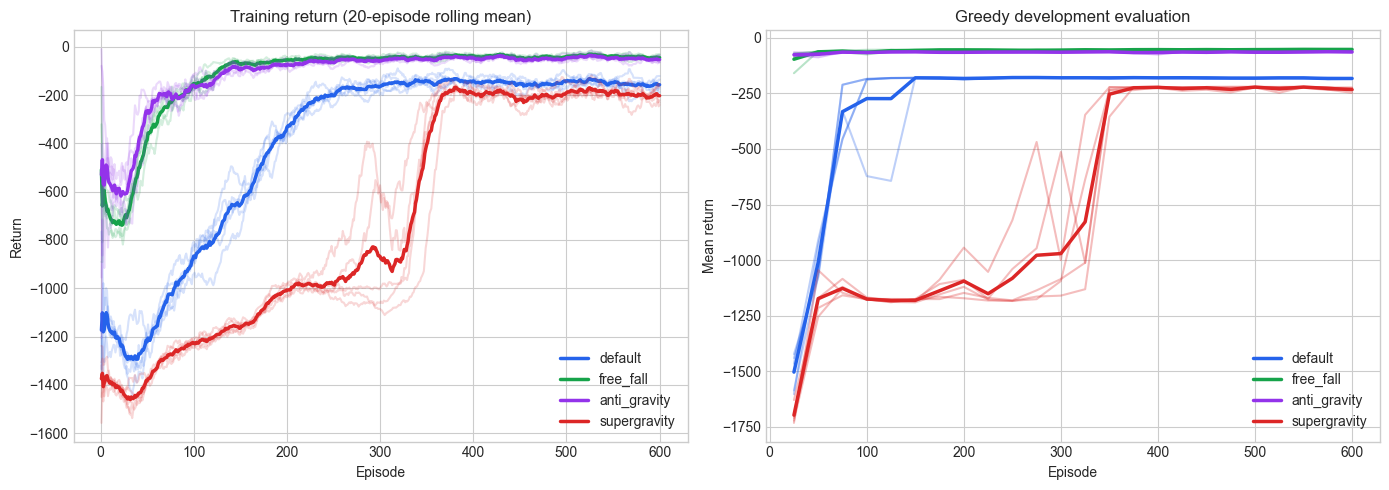

In [100]:
# Show noisy training returns separately from periodic greedy evaluation performance.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for gravity_name, runs in ALL_RUNS.items():
    color = COLORS[gravity_name]
    max_episodes = max(len(run["episode_returns"]) for run in runs)
    episode_matrix = np.full((len(runs), max_episodes), np.nan)
    for row, run in enumerate(runs):
        returns = np.asarray(run["episode_returns"], dtype=float)
        episode_matrix[row, : len(returns)] = returns
        axes[0].plot(
            np.arange(1, len(returns) + 1),
            pd.Series(returns).rolling(20, min_periods=1).mean(),
            color=color,
            alpha=0.18,
        )
    mean_curve = np.nanmean(episode_matrix, axis=0)
    axes[0].plot(
        np.arange(1, max_episodes + 1),
        pd.Series(mean_curve).rolling(20, min_periods=1).mean(),
        color=color,
        linewidth=2.5,
        label=gravity_name,
    )

    for run in runs:
        eval_frame = pd.DataFrame(run["evaluation"])
        axes[1].plot(
            eval_frame["episode"],
            eval_frame["mean_return"],
            color=color,
            alpha=0.3,
        )
    evaluation_episodes = [record["episode"] for record in runs[0]["evaluation"]]
    evaluation_matrix = np.asarray(
        [[record["mean_return"] for record in run["evaluation"]] for run in runs]
    )
    axes[1].plot(
        evaluation_episodes,
        evaluation_matrix.mean(axis=0),
        color=color,
        linewidth=2.5,
        label=gravity_name,
    )

axes[0].set(title="Training return (20-episode rolling mean)", xlabel="Episode", ylabel="Return")
axes[1].set(title="Greedy development evaluation", xlabel="Episode", ylabel="Mean return")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

### 9.2 Final Evaluation Summary

This table reports, for each gravity setting, the mean and spread of final-seed evaluation returns for the selected checkpoint, alongside the random and zero-torque reference returns from Section 3.8. Reading each gravity's result against its own reference policies is what turns a raw number into an actual verdict on whether DQN learned something useful in that setting.


,gravity,mean,median,std,ci_low,ci_high,n,random_reference,zero_torque_reference,selected_seed,selected_return,selected_upright_fraction
0,default,-164.243304,-164.292766,0.358326,-164.519265,-163.967342,5,-1192.495835,-1209.557797,55,-164.292766,0.8510
1,free_fall,-68.086989,-67.931331,0.598807,-68.625379,-67.710573,5,-751.517710,-628.898820,55,-67.575100,0.8995
2,anti_gravity,-79.893803,-79.943572,0.382044,-80.198275,-79.589332,5,-656.040290,-586.849914,44,-79.475312,0.8425
3,supergravity,-268.804271,-272.482312,6.023086,-273.321685,-264.254042,5,-1398.271864,-1411.380513,11,-272.482312,0.7685


,default,free_fall,anti_gravity,supergravity
default,-164.3,-944.8,-468.5,-882.9
free_fall,-1010.6,-67.6,-93.4,-1375.6
anti_gravity,-1431.1,-153.3,-79.5,-1555.9
supergravity,-333.7,-1322.0,-1025.0,-272.5


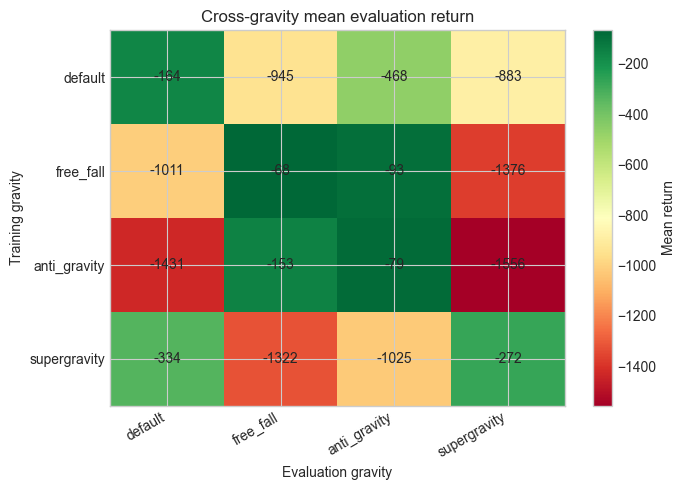

In [101]:
# Summarize all seeds, then select one model per gravity using development performance only.
summary_rows = []
SELECTED_RUNS = {}

for gravity_name, runs in ALL_RUNS.items():
    run_means = [
        float(pd.DataFrame(run["final_evaluation"])["return"].mean())
        for run in runs
    ]
    summary = summarize_values(run_means)
    random_mean = float(np.mean(reference_results[gravity_name]["random"]))
    zero_mean = float(np.mean(reference_results[gravity_name]["zero_torque"]))

    best_run = max(runs, key=lambda run: run["best_development_return"])
    SELECTED_RUNS[gravity_name] = best_run
    selected_frame = pd.DataFrame(best_run["final_evaluation"])

    summary_rows.append(
        {
            "gravity": gravity_name,
            **summary,
            "random_reference": random_mean,
            "zero_torque_reference": zero_mean,
            "selected_seed": best_run["seed"],
            "selected_return": float(selected_frame["return"].mean()),
            "selected_upright_fraction": float(selected_frame["upright_fraction"].mean()),
        }
    )

final_summary = pd.DataFrame(summary_rows)
display(final_summary)

# Evaluate each selected policy under every gravity without additional training.
TRANSFER_RESULTS = {}
transfer_matrix = pd.DataFrame(index=GRAVITY_CONFIGS, columns=GRAVITY_CONFIGS, dtype=float)

for source_gravity, selected_run in SELECTED_RUNS.items():
    source_agent = load_agent_from_checkpoint(selected_run["checkpoint_path"])
    TRANSFER_RESULTS[source_gravity] = {}
    for target_gravity in GRAVITY_CONFIGS:
        transfer_frame, _ = evaluate_agent(source_agent, target_gravity, ACTIVE_FINAL_SEEDS)
        TRANSFER_RESULTS[source_gravity][target_gravity] = transfer_frame.to_dict(orient="records")
        transfer_matrix.loc[source_gravity, target_gravity] = transfer_frame["return"].mean()

display(transfer_matrix.style.format("{:.1f}").background_gradient(cmap="RdYlGn"))

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(transfer_matrix.values.astype(float), cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(transfer_matrix.columns)), transfer_matrix.columns, rotation=30, ha="right")
ax.set_yticks(range(len(transfer_matrix.index)), transfer_matrix.index)
ax.set_xlabel("Evaluation gravity")
ax.set_ylabel("Training gravity")
ax.set_title("Cross-gravity mean evaluation return")
for row in range(len(transfer_matrix.index)):
    for column in range(len(transfer_matrix.columns)):
        ax.text(column, row, f"{transfer_matrix.iloc[row, column]:.0f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Mean return")
plt.tight_layout()
plt.show()

### 9.3 DQN Learning Diagnostics

We plot temporal-difference loss, the network's mean maximum Q-value, epsilon's decay, and replay buffer occupancy over training. A loss that keeps climbing rather than settling, or a Q-value that grows without bound, are both signs of unstable learning; these plots make it possible to notice that kind of problem instead of only seeing its downstream effect on the return.


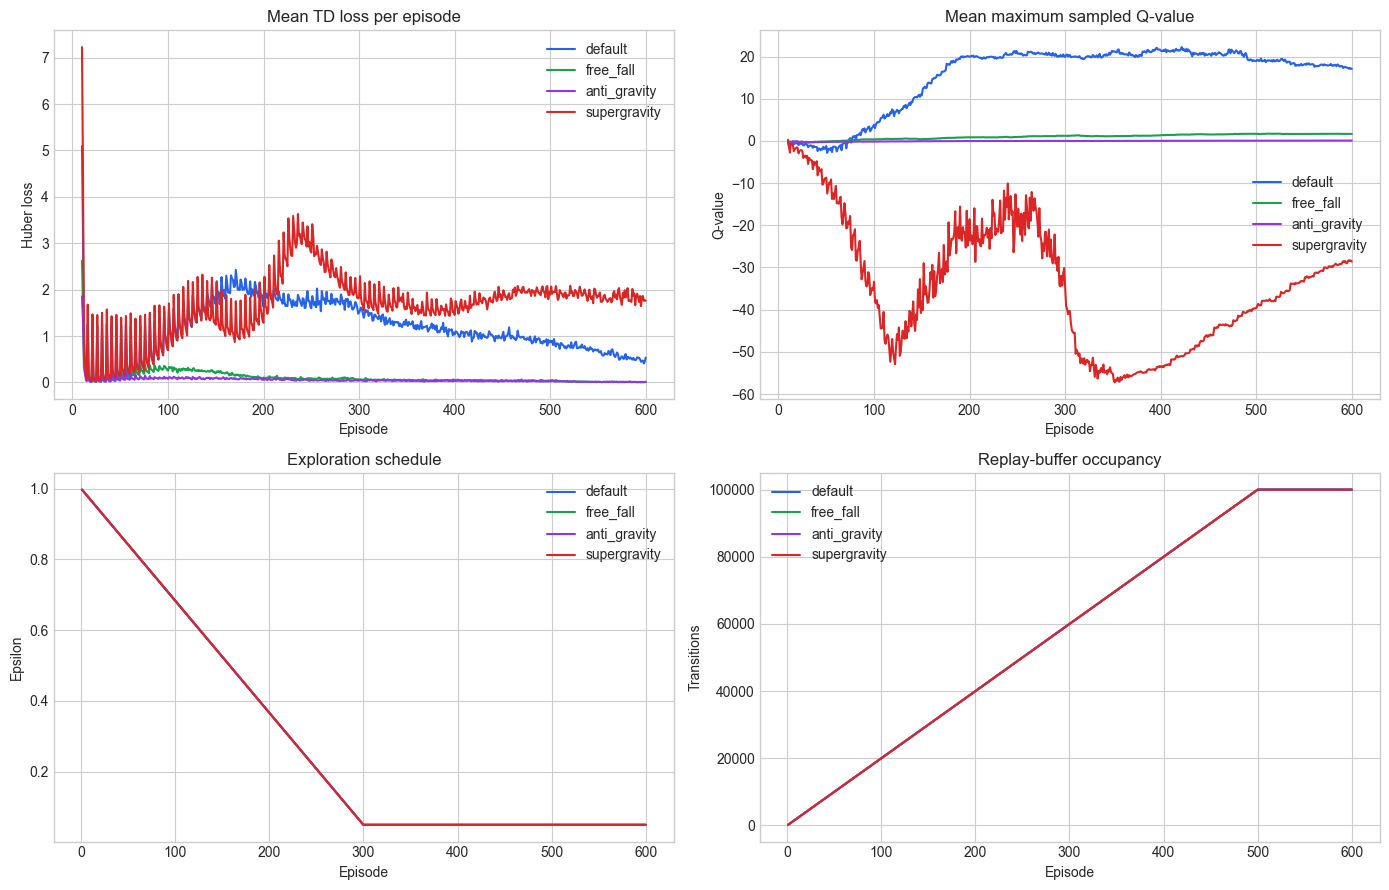

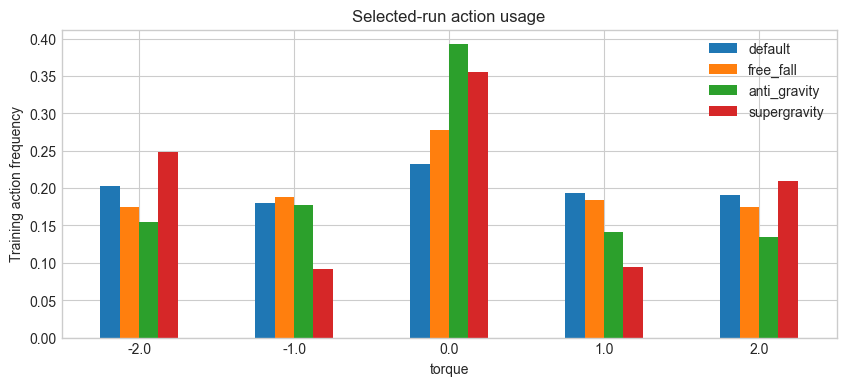

In [102]:
# Inspect optimization stability, Q-value scale, exploration decay, and replay growth.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for gravity_name, selected_run in SELECTED_RUNS.items():
    color = COLORS[gravity_name]
    episodes = np.arange(1, len(selected_run["episode_returns"]) + 1)
    axes[0, 0].plot(episodes, selected_run["losses"], color=color, label=gravity_name)
    axes[0, 1].plot(episodes, selected_run["max_q_values"], color=color, label=gravity_name)
    axes[1, 0].plot(episodes, selected_run["epsilons"], color=color, label=gravity_name)
    axes[1, 1].plot(episodes, selected_run["replay_sizes"], color=color, label=gravity_name)

axes[0, 0].set(title="Mean TD loss per episode", xlabel="Episode", ylabel="Huber loss")
axes[0, 1].set(title="Mean maximum sampled Q-value", xlabel="Episode", ylabel="Q-value")
axes[1, 0].set(title="Exploration schedule", xlabel="Episode", ylabel="Epsilon")
axes[1, 1].set(title="Replay-buffer occupancy", xlabel="Episode", ylabel="Transitions")
for ax in axes.flat:
    ax.legend()
plt.tight_layout()
plt.show()

# Check whether a selected run collapsed onto only one or two torque bins.
action_frequency = pd.DataFrame(
    {
        gravity_name: np.asarray(run["action_counts"]) / max(1, np.sum(run["action_counts"]))
        for gravity_name, run in SELECTED_RUNS.items()
    },
    index=ACTION_BINS,
)
action_frequency.index.name = "torque"
action_frequency.plot(kind="bar", figsize=(10, 4), ylabel="Training action frequency")
plt.title("Selected-run action usage")
plt.xticks(rotation=0)
plt.show()

### 9.4 Learned-Policy Behaviour

For a fixed seed under each gravity setting, we plot the pendulum's angle against its angular velocity over one greedy episode, alongside which torque bins the agent chose. This shows what the agent is actually doing moment to moment, for example whether it settles into a small oscillation near upright or applies torque erratically, in a way a single return number can't capture.


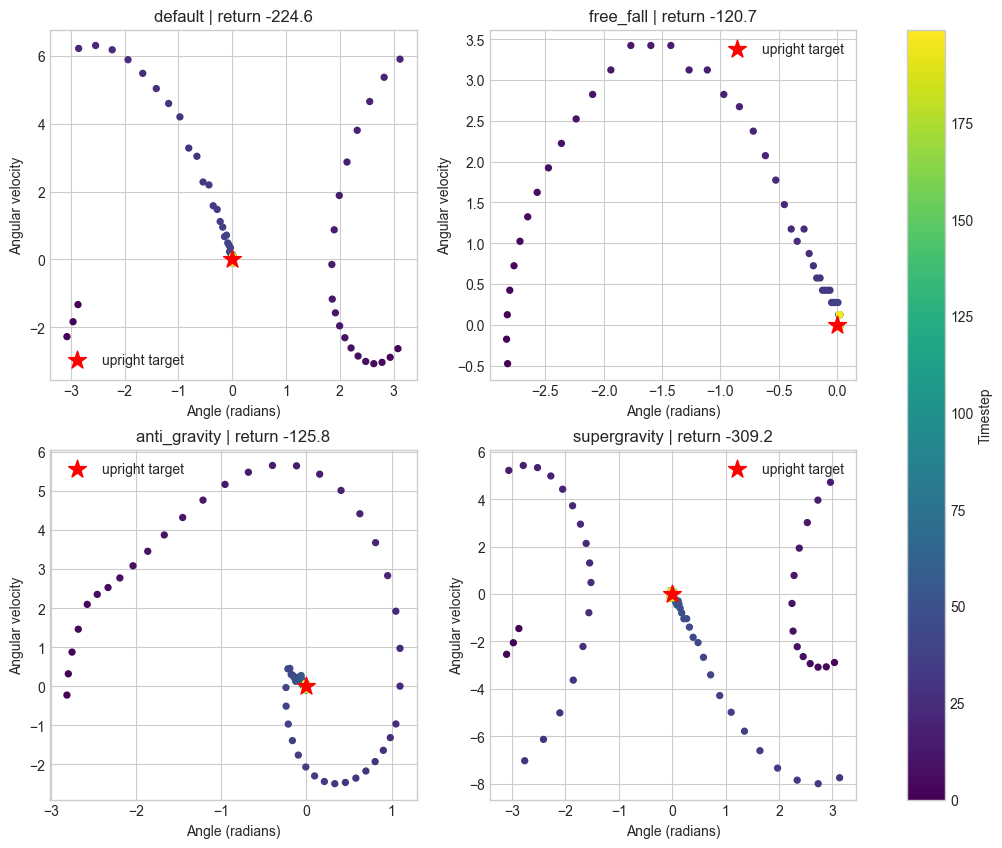

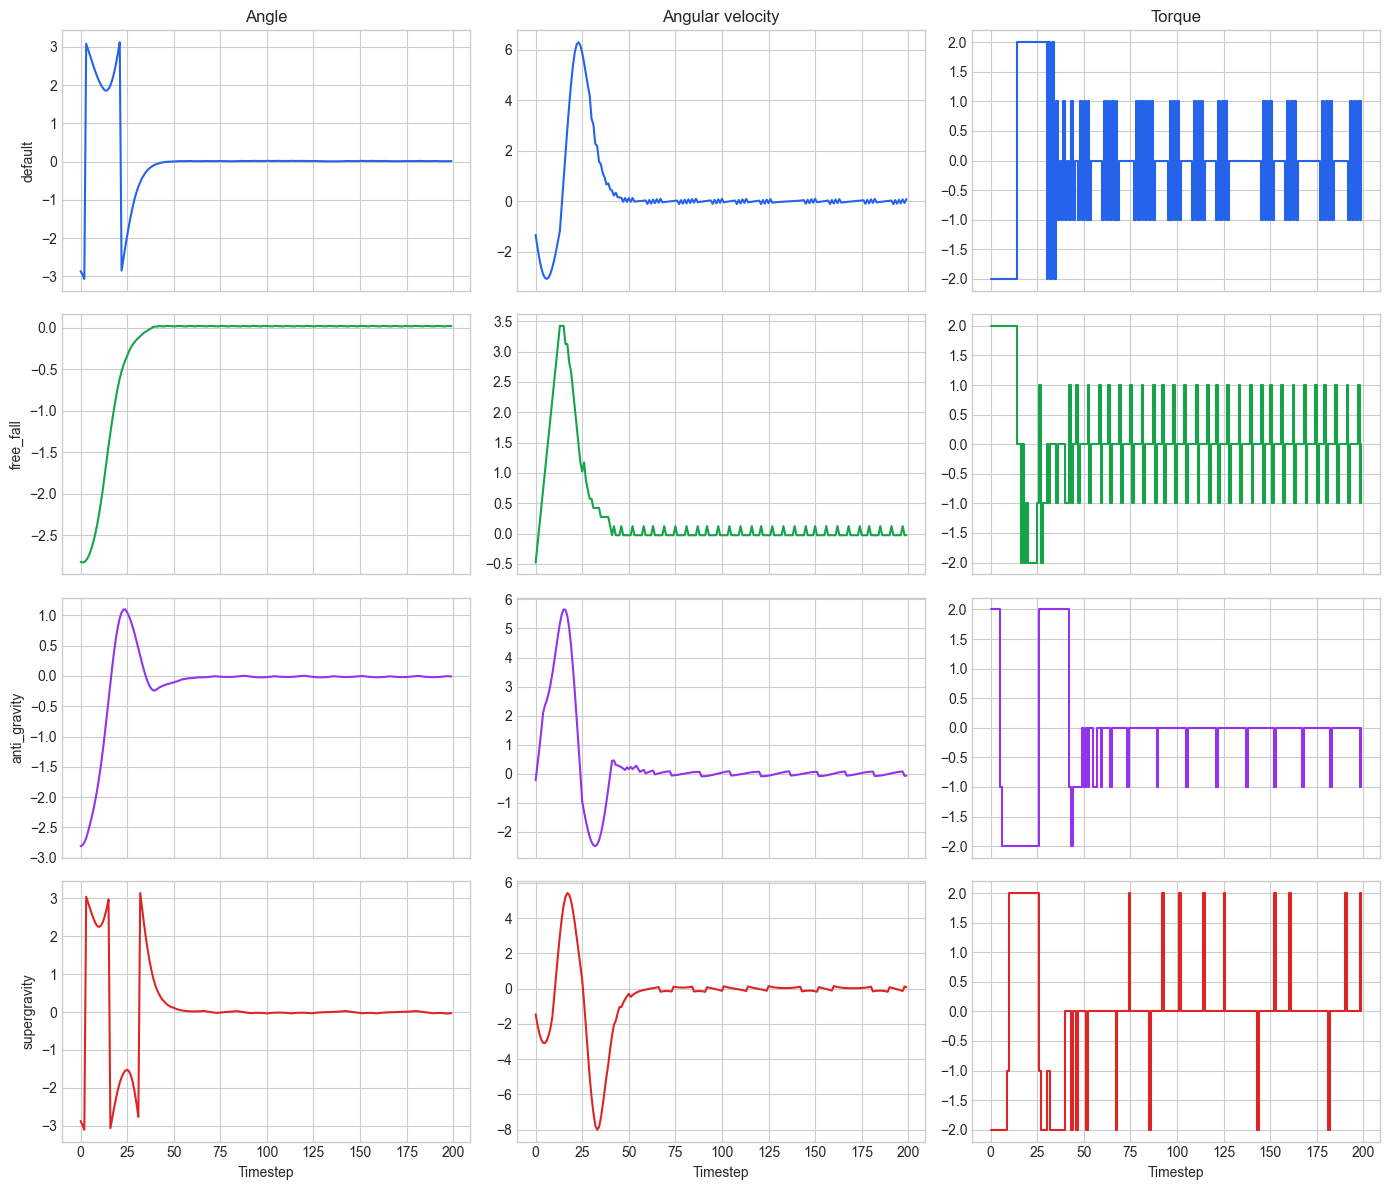

In [103]:
# Capture one fixed-seed greedy trajectory per gravity for qualitative policy analysis.
TRAJECTORIES = {}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (gravity_name, selected_run) in zip(axes.flat, SELECTED_RUNS.items()):
    agent = load_agent_from_checkpoint(selected_run["checkpoint_path"])
    _, trajectories = evaluate_agent(
        agent,
        gravity_name,
        [ACTIVE_FINAL_SEEDS[0]],
        capture_trajectories=True,
    )
    trajectory = trajectories[0]
    TRAJECTORIES[gravity_name] = trajectory
    scatter = ax.scatter(
        trajectory["angles"],
        trajectory["velocities"],
        c=np.arange(len(trajectory["angles"])),
        cmap="viridis",
        s=18,
    )
    ax.scatter([0], [0], marker="*", s=180, color="red", label="upright target")
    ax.set(
        title=f"{gravity_name} | return {trajectory['return']:.1f}",
        xlabel="Angle (radians)",
        ylabel="Angular velocity",
    )
    ax.legend()

fig.colorbar(scatter, ax=axes.ravel().tolist(), label="Timestep")
plt.show()

fig, axes = plt.subplots(len(TRAJECTORIES), 3, figsize=(14, 3 * len(TRAJECTORIES)), sharex=True)
if len(TRAJECTORIES) == 1:
    axes = np.asarray([axes])
for row, (gravity_name, trajectory) in enumerate(TRAJECTORIES.items()):
    axes[row, 0].plot(trajectory["angles"], color=COLORS[gravity_name])
    axes[row, 1].plot(trajectory["velocities"], color=COLORS[gravity_name])
    axes[row, 2].step(
        np.arange(len(trajectory["torques"])),
        trajectory["torques"],
        where="post",
        color=COLORS[gravity_name],
    )
    axes[row, 0].set_ylabel(gravity_name)
axes[0, 0].set_title("Angle")
axes[0, 1].set_title("Angular velocity")
axes[0, 2].set_title("Torque")
for ax in axes[-1]:
    ax.set_xlabel("Timestep")
plt.tight_layout()
plt.show()

### 9.5 Failure Analysis

This table flags gravity settings where the trained agent doesn't clearly beat its random-policy reference, spends little time upright, or collapses onto using almost always the same torque bin (a sign it's failed to learn any nuanced control). Separating these symptoms from each other helps identify whether a weak result under a given gravity setting comes from DQN's own limits or specifically from having only five torque bins to choose from; the two failure modes look different in this table even though they'd look identical in the mean return alone.


In [104]:
# Flag weak runs through reference-policy failures, low upright time, and action collapse.
failure_rows = []
for gravity_name, selected_run in SELECTED_RUNS.items():
    final_frame = pd.DataFrame(selected_run["final_evaluation"])
    random_mean = np.mean(reference_results[gravity_name]["random"])
    action_distribution = np.asarray(selected_run["action_counts"], dtype=float)
    action_distribution /= max(1.0, action_distribution.sum())

    failure_rows.append(
        {
            "gravity": gravity_name,
            "episodes_not_beating_random_mean": int(
                (final_frame["return"] <= random_mean).sum()
            ),
            "worst_return": float(final_frame["return"].min()),
            "mean_upright_fraction": float(final_frame["upright_fraction"].mean()),
            "dominant_action_share": float(action_distribution.max()),
            "dominant_torque": float(ACTION_BINS[action_distribution.argmax()]),
        }
    )

failure_analysis = pd.DataFrame(failure_rows)
failure_analysis

,gravity,episodes_not_beating_random_mean,worst_return,mean_upright_fraction,dominant_action_share,dominant_torque
0,default,0,-243.298008,0.8510,0.232175,0.0
1,free_fall,0,-123.871389,0.8995,0.277758,0.0
2,anti_gravity,0,-143.720793,0.8425,0.392333,0.0
3,supergravity,0,-423.033029,0.7685,0.355858,0.0


### 9.6 Watching the Trained Agent

Numbers and phase plots describe the policy, but they do not show it. For each gravity setting, we roll out one greedy episode with the selected checkpoint, capture a frame at every step, and save the sequence as a short GIF. Watching the pendulum settle (or fail to settle) makes the policy's behaviour immediate in a way that is harder to see when reading a return value in isolation, and it is the most direct way to answer whether the agent solved the task in the everyday sense of that word, not just the statistical one.

default: 201 frames -> c:\Users\kandy\Projects\playground (py)\dele\checkpoints\rl_baseline\rollout_gifs\default.gif


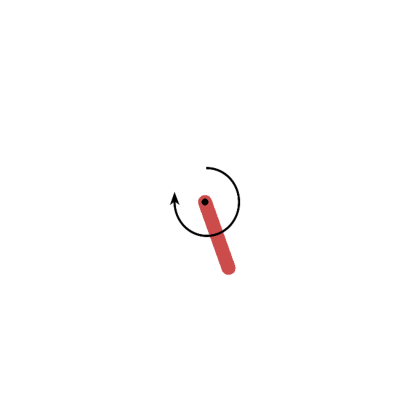

free_fall: 201 frames -> c:\Users\kandy\Projects\playground (py)\dele\checkpoints\rl_baseline\rollout_gifs\free_fall.gif


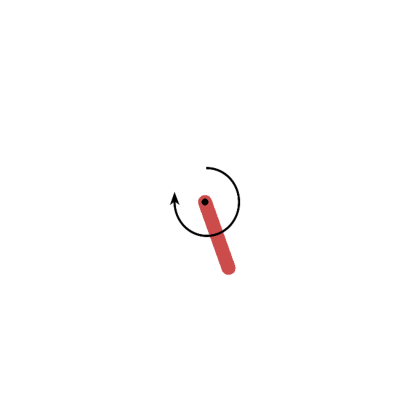

anti_gravity: 201 frames -> c:\Users\kandy\Projects\playground (py)\dele\checkpoints\rl_baseline\rollout_gifs\anti_gravity.gif


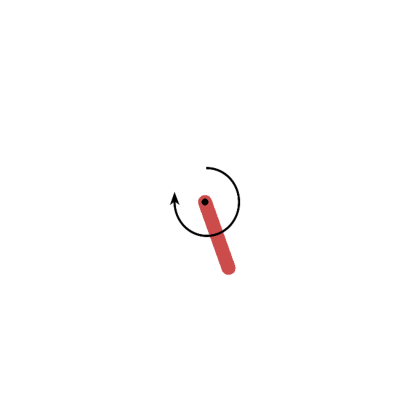

supergravity: 201 frames -> c:\Users\kandy\Projects\playground (py)\dele\checkpoints\rl_baseline\rollout_gifs\supergravity.gif


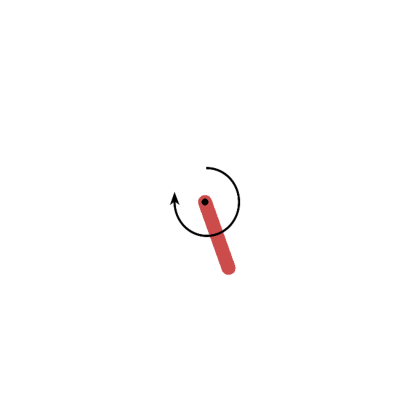

In [105]:
# Roll out one greedy episode per gravity setting and save it as a GIF for direct viewing.

# ROLLOUT_DIR is defined in Section 2 and resolves to img/rollouts/baseline/.
ROLLOUT_DIR.mkdir(parents=True, exist_ok=True)

def record_greedy_rollout(agent: DQNAgent, gravity_name: str, seed: int, max_steps: int) -> list[np.ndarray]:
    env = make_env(gravity_name, seed)
    observation = env.reset()
    frames = [env.render(mode="rgb_array")]
    for _ in range(max_steps):
        state = normalize_state(observation)
        action_index = agent.select_action(state, explore=False)
        observation, _, done, _ = env.step(action_index_to_env(action_index))
        frames.append(env.render(mode="rgb_array"))
        if done:
            break
    env.close()
    return frames

def save_rollout_gif(frames: list[np.ndarray], path: Path, fps: int = 30) -> None:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")
    image_artist = ax.imshow(frames[0])

    def update(frame_index):
        image_artist.set_data(frames[frame_index])
        return (image_artist,)

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000 / fps)
    anim.save(path, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)

for gravity_name, selected_run in SELECTED_RUNS.items():
    agent = load_agent_from_checkpoint(selected_run["checkpoint_path"])
    frames = record_greedy_rollout(agent, gravity_name, ACTIVE_FINAL_SEEDS[0], ACTIVE_CONFIG.max_steps)
    gif_path = ROLLOUT_DIR / f"{gravity_name}.gif"
    save_rollout_gif(frames, gif_path)
    print(f"{gravity_name}: {len(frames)} frames -> {gif_path}")
    display(Image(filename=str(gif_path)))


## 10. Baseline Conclusion and Improvement Handoff

This section pulls the baseline findings together, saves the deliverables, and turns the weaknesses observed above into concrete hypotheses to test in rl_improvement.ipynb.


### 10.1 Main Findings

DQN clearly beat both non-learning references in every gravity setting: across all 200 final-evaluation episodes per setting, not one fell below the random-policy mean, and mean returns landed 4-18x closer to zero than the random baseline.

Free-fall was the strongest result: mean return -68.09 (95% CI -68.63 to -67.71) against a random reference of -751.52, with the agent upright 89.95% of the time. Anti-gravity was close behind, at -79.89 (CI -80.20 to -79.59) against a random reference of -656.04, upright 84.25% of the time. Default gravity landed at -164.24 (CI -164.52 to -163.97) against a random reference of -1192.50, upright 85.10% of the time; the return looks worse than anti-gravity or free-fall mainly because default gravity's reward scale is larger, not because control was worse.

Supergravity was the clear weak point: mean return -268.80 (CI -273.32 to -264.25) against a random reference of -1398.27, upright only 76.85% of the time, and the seed-to-seed standard deviation (6.02) was 10-17x every other setting's (0.36-0.60). DQN still learned a working policy here, but it was the least stable and least precise of the four.


### 10.2 Limitations, Threats to Validity, and Improvement Hypotheses

The baseline's conclusions are limited by the number of seeds tested, the five-bin torque discretization, and the compute budget available for training.

The action-collapse check in Section 9.5 doesn't show a real collapse anywhere: the most any single torque bin dominates a setting's actions is 39.2% (anti-gravity), against 20% for a uniform pick over five bins, so the agent isn't just spamming one action in any setting, including supergravity. That weakens the case for finer discretization as the main fix and points instead at learning instability: supergravity's return standard deviation (6.02) is 10-17x the other three settings, which looks like the kind of run-to-run variance double DQN is meant to reduce by correcting Q-value overestimation. Finer torque bins are still worth testing for supergravity specifically, since it's the setting demanding the most torque against the fixed [-2, 2] range, but the variance numbers make double DQN the higher-priority hypothesis for the improvement notebook.


### 10.3 Save Baseline Artifacts

We save the best-performing weights for each gravity setting as .h5 files, together with the hyperparameter configuration, per-seed training histories, and evaluation results as JSON, so the full baseline can be reproduced or reused without retraining.


In [106]:
# Export raw PyTorch tensors into a genuine HDF5 file for the assignment deliverable.
def export_state_dict_h5(
    model: nn.Module,
    path: Path,
    config: DQNConfig,
    metadata: dict,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with h5py.File(path, "w") as handle:
        state_group = handle.create_group("state_dict")
        for name, tensor in model.state_dict().items():
            state_group.create_dataset(name, data=tensor.detach().cpu().numpy())
        handle.attrs["config_json"] = json.dumps(asdict(config))
        handle.attrs["metadata_json"] = json.dumps(json_ready(metadata))

# Reconstruct a PyTorch state_dict from HDF5 and return its stored metadata.
def load_state_dict_h5(model: nn.Module, path: Path) -> dict:
    with h5py.File(path, "r") as handle:
        expected = model.state_dict()
        loaded = {
            name: torch.as_tensor(handle["state_dict"][name][...], dtype=expected[name].dtype)
            for name in expected
        }
        model.load_state_dict(loaded)
        metadata = json.loads(handle.attrs["metadata_json"])
    return metadata

selected_artifacts = {}
for gravity_name, selected_run in SELECTED_RUNS.items():
    selected_agent = load_agent_from_checkpoint(selected_run["checkpoint_path"])
    source_pt = Path(selected_run["checkpoint_path"])
    exported_pt = NOTEBOOK_DIR / f"rl_baseline_best_{gravity_name}.pt"
    exported_h5 = MODEL_CHECKPOINT_DIR / f"rl_baseline_best_{gravity_name}.h5"

    source_payload = safe_torch_load(source_pt)
    torch.save(source_payload, exported_pt)
    export_state_dict_h5(
        selected_agent.online_network,
        exported_h5,
        selected_agent.config,
        {
            "gravity": gravity_name,
            "seed": selected_run["seed"],
            "source_checkpoint": str(source_pt),
        },
    )

    pt_network = QNetwork(
        selected_agent.config.state_dim,
        selected_agent.config.action_dim,
        selected_agent.config.hidden_dims,
    )
    pt_network.load_state_dict(safe_torch_load(exported_pt)["model_state"])

    h5_network = QNetwork(
        selected_agent.config.state_dim,
        selected_agent.config.action_dim,
        selected_agent.config.hidden_dims,
    )
    h5_metadata = load_state_dict_h5(h5_network, exported_h5)

    # Verify that .pt and .h5 exports produce identical Q-values after reloading.
    verification_states = torch.tensor(
        [[1.0, 0.0, 0.0], [0.0, 1.0, 0.25], [-1.0, 0.0, -0.5]],
        dtype=torch.float32,
    )
    with torch.no_grad():
        pt_outputs = pt_network(verification_states)
        h5_outputs = h5_network(verification_states)
    assert torch.allclose(pt_outputs, h5_outputs, atol=1e-7, rtol=1e-6)

    selected_artifacts[gravity_name] = {
        "pt": str(exported_pt),
        "h5": str(exported_h5),
        "h5_metadata": h5_metadata,
    }

# Save raw histories and derived summaries so every reported figure is reproducible.
results_payload = {
    "schema_version": 1,
    "reproducibility": reproducibility_record,
    "reference_results": reference_results,
    "runs": {
        gravity_name: [
            {key: value for key, value in run.items() if key != "agent"}
            for run in runs
        ]
        for gravity_name, runs in ALL_RUNS.items()
    },
    "selected_runs": {
        gravity_name: {
            key: value
            for key, value in run.items()
            if key not in {"agent"}
        }
        for gravity_name, run in SELECTED_RUNS.items()
    },
    "final_summary": final_summary.to_dict(orient="records"),
    "transfer_results": TRANSFER_RESULTS,
    "selected_artifacts": selected_artifacts,
}

if RUN_PROFILE == "full":
    results_path = RESULTS_DIR / "rl_baseline_results.json"
else:
    results_path = CHECKPOINT_ROOT / "smoke_results.json"

results_path.write_text(
    json.dumps(json_ready(results_payload), indent=2, allow_nan=True),
    encoding="utf-8",
)

print(f"Saved results: {results_path}")
display(pd.DataFrame(selected_artifacts).T)

Saved results: c:\Users\kandy\Projects\playground (py)\dele\rl_baseline_results.json


,pt,h5,h5_metadata
default,c:\Users\kandy\Projects\playground (py)\dele\c...,c:\Users\kandy\Projects\playground (py)\dele\m...,"{'gravity': 'default', 'seed': 55, 'source_che..."
free_fall,c:\Users\kandy\Projects\playground (py)\dele\c...,c:\Users\kandy\Projects\playground (py)\dele\m...,"{'gravity': 'free_fall', 'seed': 55, 'source_c..."
anti_gravity,c:\Users\kandy\Projects\playground (py)\dele\c...,c:\Users\kandy\Projects\playground (py)\dele\m...,"{'gravity': 'anti_gravity', 'seed': 44, 'sourc..."
supergravity,c:\Users\kandy\Projects\playground (py)\dele\c...,c:\Users\kandy\Projects\playground (py)\dele\m...,"{'gravity': 'supergravity', 'seed': 11, 'sourc..."
